In [2]:
from importlib import reload
import sys
import subprocess

import scipy
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../python")
import pymodelica
reload(pymodelica)


<module 'pymodelica' from '/mnt/c/Users/Tom/Documents/ThermalModel/python/pymodelica.py'>

# Run the simualtion

In [11]:
MODEL_NAME = "System_LMO_exe"
MODEL_FILE = "../System_LMO.mo"
MODEL_FILE_LIN = "../build/linearized_model.py"
EQUILIBRIUM_TIME = 20.0
# PARAMS = "../parameters/params_lmo_v1_mod_tes.txt"
PARAMS = "../parameters/params_lmo_v1_mod_absorber.txt"
# PARAMS = "../parameters/params_lmo_v1_default.txt"
# PARAMS = "../parameters/params.txt"


In [18]:
# Step 1. a fast/coarse simulation to reach equilibrium
log = subprocess.run(
    [
        f"./{MODEL_NAME}",
        # "-lv=-LOG_STDOUT",
        f"-overrideFile={PARAMS}",
        "-startTime=0",
        f"-stopTime={EQUILIBRIUM_TIME}",
        "-stepSize=2e-4",
        "-tolerance=1e-8",
        "-s=dassl",
        "-w", # Show all warnings
        "-outputFormat=mat",
        f"-r={MODEL_NAME}_res_init.mat", # Result filename
        f"-l={EQUILIBRIUM_TIME}", ## Perform linearization
    ],
    cwd="../build",
    check=True,
    capture_output=True, text=True
)
log.stderr, log.stdout


('',
 'LOG_STDOUT        | warning | You are overriding Bias_C with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Bias_L with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Edep_time with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K4 with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K7 with a small value or zero.\n|                 | |       |

In [13]:
reload(pymodelica)

<module 'pymodelica' from '/mnt/c/Users/Tom/Documents/ThermalModel/python/pymodelica.py'>

In [14]:
# Plot all C and G to check if the system is at equilibrium

filename_init = f'../build/{MODEL_NAME}_res_init.mat'
time_steps_init, data_init = pymodelica.load_om_mat(filename_init)

pymodelica.mod_svg("../System_LMO.svg", "temp_image.svg", data_init, system_name="System_LMO", width=1500, display=True)

In [19]:

# Step 2: Compile another simulation with fine resolution starting from the final values of Step 1
# Using -iif (Import Initial File) and -iit (Import Initial Time) to reset startTime = 0.0
log2 = subprocess.run(
    [
        f"./{MODEL_NAME}",
        f"-r={MODEL_NAME}_res_final.mat",
        f"-overrideFile={PARAMS}",
        "-s=dassl",
        "-w",
        "-startTime=0",
        "-stopTime=0.1",
        "-stepSize=1e-6",
        "-tolerance=1e-8",
        f"-iif={MODEL_NAME}_res_init.mat",
        f"-iit={EQUILIBRIUM_TIME}",
        "-lv=-LOG_STDOUT",
    ],
    cwd="../build",
    check=True,
    capture_output=True, text=True
)
log2.stderr, log2.stdout

('',
 'LOG_STDOUT        | warning | You are overriding Bias_C with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Bias_L with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Edep_time with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K4 with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K7 with a small value or zero.\n|                 | |       |

In [ ]:
filename = f'../build/{MODEL_NAME}_res_final.mat'

time_steps, data = pymodelica.load(filename)
print(data.keys())

dict_keys(['CL.v', 'L.i', 'c1.T', 'c10.T', 'c2.T', 'c3.T', 'c4.T', 'c5.T', 'c6.T', 'c7.T', 'c8.T', 'c9.T', 'der(CL.v)', 'der(L.i)', 'der(c1.T)', 'der(c10.T)', 'der(c2.T)', 'der(c3.T)', 'der(c4.T)', 'der(c5.T)', 'der(c6.T)', 'der(c7.T)', 'der(c8.T)', 'der(c9.T)', 'C1', 'C10', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'CL.i', 'G1', 'G10', 'G11', 'G12', 'G13', 'G14', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'GND.p.i', 'GND.p.v', 'HeatSource.port.Q_flow', 'HeatSource1.port.Q_flow', 'L.v', 'RL.LossPower', 'RL.R_actual', 'RL.i', 'c1.P_Joule', 'c1.R', 'c1.cp', 'c1.heatPort.Q_flow', 'c1.v', 'c10.cp', 'c10.port.Q_flow', 'c2.cp', 'c2.port.Q_flow', 'c3.cp', 'c3.port.Q_flow', 'c4.cp', 'c4.port.Q_flow', 'c5.cp', 'c5.port.Q_flow', 'c6.cp', 'c6.port.Q_flow', 'c7.cp', 'c7.port.Q_flow', 'c8.cp', 'c8.port.Q_flow', 'c9.cp', 'c9.port.Q_flow', 'edep_film.y', 'edep_target.y', 'fixedTemperature.port.Q_flow', 'g1.Q_flow', 'g10.Q_flow', 'g11.Q_flow', 'g12.Q_flow', 'g13.Q_flow', 'g14.Q_flow', 'g2.Q

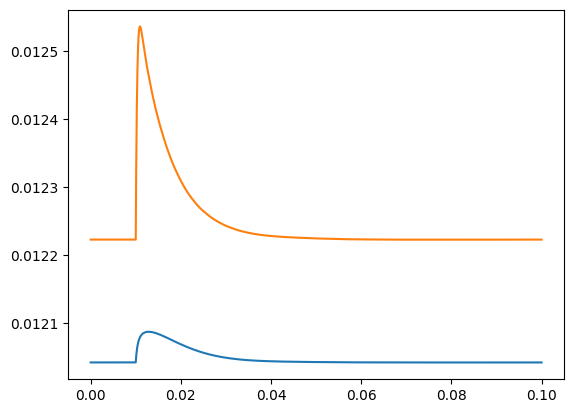

In [21]:
# plt.plot(time_steps, data['tes.i'])
plt.plot(time_steps, data['T1'])
plt.plot(time_steps, data['T2'])
# plt.plot(time_steps, data['T10'])

# Complex impedance

In [21]:
reload(pymodelica)

<module 'pymodelica' from '/mnt/c/Users/Tom/Documents/ThermalModel/python/pymodelica.py'>

In [ ]:
class TESModel:
    def __init__(self, linearized_model_filename, full_model_filename, simulation_results, config, f_min = 1, f_max = 100e3, points = 1000):
        """
        config: dict
            Dictionary containing the configuration parameters for the analysis. List of parameters:
            "L": Inductance value of the TES circuit in Henrys (H).
            "RL": Resistance value of the TES circuit in Ohms (Ω).
            
        We need to follow some conventions for the model to work properly. The first state variable must be the voltage across the TES, the second state variable must be the current through the TES. The third state variable must be the temperature of the TES. The rest of the state variables are the temperatures of each heat capacity cN, where N is the 1-based index of the heat capacity following increasing order. Example:
        
        ['CL_v','L_i','c1_T','c2_T','c3_T','c4_T','c5_T','c6_T','c7_T','c8_T','c9_T','c10_T']
        """
        self.simulation_results = simulation_results
        self.config = config
        
        self.frequencies = np.logspace(np.log10(f_min), np.log10(f_max), points)
        self.iw = 2j*np.pi*self.frequencies

        # Load models
        self.model = pymodelica.load_linearized_model(linearized_model_filename)
        self.model_conductance_map = pymodelica.parse_thermal_conductance_connections(full_model_filename)
        self.nparams = len(self.model["x0"])
        
        # hardcoded parameters
        self.n_capacities = self.nparams - 2 # First 2 are TES V and I, the rest are heat capacities
        self.index_tes_v = 0
        self.index_tes_i = 1
        self.index_tes_c = 2
        
        # Coefficients to be multiplied to external input if the input is given as [dV, dVbias, dP, ...]
        self.external_input_coeff = np.zeros(self.nparams)
        self.external_input_coeff[0] = 1/self.simulation_results[f"RL.R"][-1]/self.simulation_results[f"CL.C"][-1]
        self.external_input_coeff[1] = 1/self.simulation_results[f"L.L"][-1]
        for i in range(2, self.nparams):
            self.external_input_coeff[i] = 1/self.simulation_results[f"c{i-1}.C"][-1]        
        
        # Calculate the matrix and the inverse of the matrix for each frequency
        self.matrices = {iw: self.get_matrix(iw) for iw in self.iw}
        self.matrices_inv = {iw: np.linalg.inv(matrix) for iw, matrix in self.matrices.items()}


    def get_matrix(self, iw):
        """
        Compute the matrix of the system of equations for a given frequency iw
        ---
        iw: complex float, complex frequency
        A: array of complex float, matrix of the system of equations
        """
        A = self.model["A"]
        N = - A + iw*np.eye(A.shape[0]) # Compute eigenvectors
        return N
        
        
    def get_solution_full(self, external_input, norm = True):
        d_out = []
        for iw in self.iw:
            if norm:
                d_in = external_input * self.external_input_coeff
            else:
                d_in = external_input
            d_out.append(self.matrices_inv[iw].dot(d_in))
        d_out = np.array(d_out)
        return d_out
        
    def get_solution_single(self, index_input, index_output):
        d_out = []
        for iw in self.iw:
            d_in = np.zeros(self.nparams)  # Pulse to Absorber
            d_in[index_input] = self.external_input_coeff[index_input]
            d_out.append(self.matrices_inv[iw].dot(d_in)[index_output])
        d_out = np.array(d_out)
        return d_out
    
    def get_dIdP(self, index_cinput = -1):
        ind_c = self.nparams - 1 + index_cinput if index_cinput < 0 else index_cinput - 1 # for example, -1 -> len - 2; 2 -> 1
        self.dIdP = self.get_solution_single(index_input=ind_c, index_output=self.index_tes_i)
        return self.dIdP
    
    def get_dIdV(self):
        self.dIdV = self.get_solution_single(index_input=self.index_tes_i, index_output=self.index_tes_i)
        return self.dIdV
        
            
    def get_impedance(self):
        dI = self.get_solution_single(index_input=self.index_tes_i, index_output=self.index_tes_i)
        dV = self.get_solution_single(index_input=self.index_tes_i, index_output=self.index_tes_v)
        self.Z_TES = dV/dI
        return self.Z_TES
    

    
    @staticmethod
    def noise_phonon(K,T1,T2,n):
        """
        Phonon noise density, or say thermal fluctuation noise between 2 components. Defined as noise=sqrt( 2*kb*(G1*T1^2 + G2*T2^2) )
        Since G = nKT1^(n-1), nosie = sqrt( 2*kb*n*K*(T1^(n+1) + T2^(n+1)) )
        ---
        K: float
            conductance constant as defined in P = K*(T1^n - T2^n)
        T1,T2: float
            temperature of component 1 and 2
        n: float
            exponent of thermal conductance
        ---
        noise: float
            phonon noise
        """
        noise = np.sqrt(2.* scipy.constants.k * n * K * (T1**(n+1) + T2**(n+1)))
        return noise
    
    
    def get_noise(self, 
                    RL_temperature = None, 
                    noise_electronics = 0, 
                    noise_flicker_corner = 1e-6, 
                    noise_flicker_gamma = 1,
                    index_cinput = -1):
        """
        Compute the noise density.
        ---
        RL_temperature: float
        noise_electronics: float, in A/sqrt(Hz)
            Additional electronic noise, e.g. from the readout electronics
        noise_flicker_corner: float, in Hz
            Corner frequency of the flicker noise, below which the noise increases as 1/f^gamma
        noise_flicker_gamma: float
            Exponent of the flicker noise, below the corner frequency. The noise increases as 1/f^gamma
        index_cinput: int
            Zero-based index of the heat capacity where the input power is applied. If negative, it counts from the end of the list. For example, -1 means the last heat capacity, -2 means the second to last, etc. For example, if the list of parameters is ['CL_v','L_i','c1_T','c2_T','c3_T','c4_T','c5_T','c6_T','c7_T'], then index_cinput = -1 means c17, index_cinput = -2 means c9, index_cinput = 2 means c1, index_cinput = 3 means c2 etc.
        """
        # Initialize the noise source vectors
        self.noise_source_vectors = {}
                
        ## 1. Thermal noise (passive + active)
        TES_R0 = self.simulation_results["c1.R"][-1]
        TES_T0 = self.simulation_results["c1.T"][-1]
        TES_beta = self.simulation_results["c1.beta0"][-1]
        BIAS_RL = self.simulation_results["RL.R"][-1]
        BIAS_L = self.simulation_results["L.L"][-1]
        BIAS_T = RL_temperature if RL_temperature is not None else TES_T0
        
        # External Johnson Noise across shunt resistor
        self.noise_source_vectors["External Johnson noise"] = np.zeros(self.nparams)        
        self.noise_source_vectors["External Johnson noise"][0] = np.sqrt(4.*scipy.constants.k * BIAS_T*BIAS_RL)         
        # Internal Johnson Noise, also called TES Johnson Noise
        self.noise_source_vectors["TES Johnson noise"] = np.zeros(self.nparams)
        self.noise_source_vectors["TES Johnson noise"][1] = np.sqrt(4.*scipy.constants.k * TES_T0*TES_R0 * (1+2*TES_beta)) 

        ## 2. Phonon noise
        for i in self.model_conductance_map:
            ## Index of the two ends
            inds = self.model_conductance_map[i]
            K =  self.simulation_results[f"g{i}.K"][-1]
            n =  self.simulation_results[f"g{i}.n"][-1]
            T1 =  self.simulation_results[f"g{i}.port_a.T"][-1]
            T2 =  self.simulation_results[f"g{i}.port_b.T"][-1]
            
            ## Make a noise vector for each phonon noise term, with the noise term in the two ends of the conductance
            TFN = self.noise_phonon(K,T1,T2,n)
            self.noise_source_vectors[f"TFN_{i}"] = np.zeros(self.nparams)
            if inds[0]!=0:
                self.noise_source_vectors[f"TFN_{i}"][inds[0]+1] = TFN
            if inds[1]!=0:
                self.noise_source_vectors[f"TFN_{i}"][inds[1]+1] = -TFN
            print(i, TFN)

        ## 3. Readout noise (electronics + flicker noise)
        ##    It is directly given, and does not go into noise_source_vectors
        self.noise_readout = np.ones(len(self.iw)) * noise_electronics
        self.noise_flicker = (self.frequencies[1:] / noise_flicker_corner) ** (-noise_flicker_gamma)* noise_electronics
        self.noise_flicker = np.concatenate([[self.noise_flicker[0]], self.noise_flicker]) 
        self.noise_readout = np.sqrt(self.noise_readout**2 + self.noise_flicker**2)
        

        ## Convert all noise terms into TES current
        self.noise_current = {key: self.get_solution_full(self.noise_source_vectors[key])[:, self.index_tes_i].real for key in self.noise_source_vectors}
        self.noise_current["Readout noise"] = self.noise_readout

        ## Also convert it into target energy deposition
        dIdP = self.get_dIdP(index_cinput = index_cinput)
        self.noise_power = {key: self.noise_current[key]/dIdP for key in self.noise_current}
        self.noise_power_square_sum = np.sum(np.square(list(self.noise_power.values())), axis=0)

        
        # Integrate the NEP
        self.noise_power_integral = np.sum(1/self.noise_power_square_sum) * (self.frequencies[1] - self.frequencies[0])  # Approximate the integral using the trapezoidal rule
        # Compute the resolution of our detector
        resolution_sigma = np.sqrt(4.*self.noise_power_integral)**(-1.)
        resolution_sigma_ev = resolution_sigma/scipy.constants.e
        
        print("Resolution (Sigma) in eV = ",resolution_sigma_ev)
        
        # Compute an ideal TES resolution
        # ctot = cg + ca + cau1 + cwb1 + cau2 + csi + cte + cm + cwb2
        # rough_resolution = np.sqrt(4*p['kb']*p['Tc']**2*ctot/p['alpha0']*np.sqrt(p['ntem']/2.)) # In sigma
        # # Convert this to eV
        # rough_resolution_ev = rough_resolution/p['eVtoJ']
        # ideal_resolution = rough_resolution_ev
        # print("Ideal Resolution in eV = ",rough_resolution_ev)

        return self.noise_current, self.frequencies

In [183]:
MODEL_FILE = "../System_LMO.mo"
MODEL_FILE_LIN = "../build/linearized_model.py"

filename = f'../build/{MODEL_NAME}_res_final.mat'
time_steps, simulation_results = pymodelica.load(filename)

model = TESModel(MODEL_FILE_LIN, 
                 MODEL_FILE, 
                 simulation_results = simulation_results,
                 config={"L": 0.3e-6, "RL": 0.02}, 
                 f_min = 1, f_max = 100e3, points = 1000)

In [184]:
noise_current, frequencies = model.get_noise(RL_temperature = 0.1,
    noise_electronics = 0,
    noise_flicker_corner = 1,
    noise_flicker_gamma = 1,
    index_cinput = -1)

1 1.0110222611301344e-17
2 4.215392039283673e-17
3 4.220845553040516e-17
4 2.1916413110078352e-18
5 2.6688118302979723e-19
6 1.763563635720624e-20
7 2.238411062171607e-18
8 3.900561361326723e-18
9 1.0378221337176627e-16
10 1.0376232307846879e-16
11 3.4885017876203835e-19
12 3.893368032705785e-19
13 3.8661223196807416e-19
14 2.084982757461645e-17
Resolution (Sigma) in eV =  (3295.174053739976+1392.321105284399j)


In [187]:
for key in noise_current:
    # plt.plot(np.sqrt(abs(noise_current[key])), label=key)
    print(key, np.sqrt(abs(noise_current[key])[-1]))


TES Johnson noise 5.689162563704617e-07
External Johnson noise 6.045194791103336e-07
TFN_1 1.959299879284708e-09
TFN_2 4.9727434859166144e-08
TFN_3 1.639702712221814e-07
TFN_4 1.3273759081070297e-06
TFN_5 1.2462735297306889e-08
TFN_6 1.1911375062424013e-07
TFN_7 1.2791809045468434e-06
TFN_8 5.349264391601291e-07
TFN_9 9.174877937845493e-08
TFN_10 7.590179513307472e-08
TFN_11 7.005132728530136e-09
TFN_12 1.2533069379872656e-09
TFN_13 1.3739303089796699e-11
TFN_14 2.448690911304833e-11
Readout noise 0.0


In [186]:
a = np.zeros(12)
a[1] = 3.32343076e-13
model.matrices_inv[6.283185307179586j].dot(model.noise_source_vectors['External Johnson noise'])

array([ 1.67455730e-25-4.93474895e-30j, -1.72592498e-24+2.46737426e-28j,
        4.77340656e-22-3.24963398e-26j,  1.46890554e-23-6.55302590e-25j,
        1.54000692e-23-6.55671291e-25j,  1.61099320e-23-6.54565021e-25j,
        4.79238981e-24-2.27311304e-25j,  7.90970198e-23-5.50409260e-27j,
        2.10400480e-25-2.01858261e-29j,  1.05213683e-25-1.02170166e-29j,
        2.40943441e-24-1.98641982e-25j,  2.83621797e-24-1.81507940e-25j])

In [176]:
model.get_solution_full(model.noise_source_vectors['External Johnson noise'])[1]

array([ 8.62962353e-14-1.24792299e-17j, -4.31481177e-12+6.23961484e-16j,
        1.19335154e-09-8.21776321e-14j,  3.67208713e-11-1.65716155e-12j,
        3.84984050e-11-1.65809396e-12j,  4.02730651e-11-1.65529637e-12j,
        1.19802623e-11-5.74826903e-13j,  1.97742532e-10-1.39189170e-14j,
        5.26001138e-13-5.10464813e-17j,  2.63034177e-13-2.58370956e-17j,
        6.02282468e-12-5.02314971e-13j,  7.08999930e-12-4.59002613e-13j])

In [181]:
model.matrices_inv[6.283185307179586j]

array([[ 5.03864055e-13-1.48483579e-17j,  7.78980413e-08-1.11362675e-11j,
         2.64797670e-10-1.80268639e-14j,  4.62188044e-08-2.06188756e-09j,
         2.42298549e-09-1.03160273e-10j,  3.49432544e-11-1.41977826e-12j,
         8.05632729e-13-4.02922481e-14j,  1.90099135e-12-1.32276298e-16j,
         7.98327050e-13-7.51906306e-17j,  2.48722300e-12-2.37162999e-16j,
         2.11040262e-11-1.79461890e-12j,  2.63441762e-08-1.68592957e-09j],
       [-5.19320275e-12+7.42417834e-16j, -3.89490206e-06+5.56813366e-10j,
        -1.32398835e-08+9.01343163e-13j, -2.31094022e-06+1.03094378e-07j,
        -1.21149274e-07+5.15801365e-09j, -1.74716272e-09+7.09889129e-11j,
        -4.02816365e-11+2.01461241e-12j, -9.50495677e-11+6.61381467e-15j,
        -3.99163525e-11+3.75953143e-15j, -1.24361150e-10+1.18581496e-14j,
        -1.05520131e-09+8.97309449e-11j, -1.31720881e-06+8.42964787e-08j],
       [ 1.43628886e-09-9.77795000e-14j,  1.07721664e-03-7.33346223e-08j,
         2.02409131e-06-9.77180059e-

In [169]:
model.noise_source_vectors['External Johnson noise']

array([0.00000000e+00, 3.32343076e-13, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

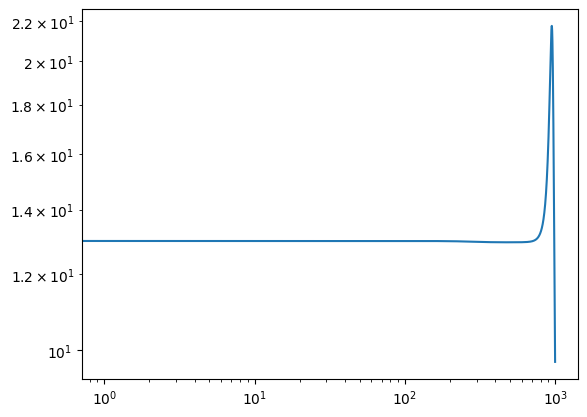

In [143]:
dvdi = model.get_dIdV()
plt.loglog(np.abs(dvdi))